# SEIRS-SEI Malaria Model — IC Calibration with Warm-Up

Calibrating the **2012 initial conditions** (S_H0_frac, E_H0_frac, I_M0_ratio for the warm-up start)
to match observed I_H over 2017–2023.

After warm-up (2012–2016), the system state becomes the 2017 initial condition.
By fitting the 2012 ICs, we find which warm-up trajectory best matches the data.

R_H0 is computed as residual: R_H0 = N - S_H0 - E_H0 - I_H0, constrained to [1%, 85%] of N.


In [2]:
import sys
sys.path.append("..")

from ode_models.seirs_sei_ode_shared import *
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
from scipy.optimize import minimize


Data loaded and filtered successfully!
Climate data: 2556 days
Cases data: 2556 days
Deforestation data: 3288 days
Forest fires data: 3288 days

IBGE rural population by year (2017-2023):
2017: 8368.62
2018: 8260.48
2019: 8152.73
2020: 8045.43
2021: 7938.61
2022: 7832.33
2023: 7942.25
The initial ratio of exposed to infected mosquitos in 2012 was estimated to be ~4
The initial ratio of exposed to infected mosquitos was estimated to be ~3
Initial human compartments in 2017: N=8369, S_H=5752, E_H=418, I_H=944, R_H=1255
Initial mosquito compartments in 2017: M=83690, S_M=80342, E_M=2511, I_M=837


## Load Extended Climate Data (2012–2024)

Concatenate 2012–2015 and 2016–2024 climate data for a continuous 2012–2023 simulation.


In [4]:
#### Load and concatenate climate data 2012-2024
climate_2012_2015 = pd.read_csv(
    os.path.join(DATA_DIR, "climate_api_data_2012_2015.csv")
)
climate_2016_2024 = pd.read_csv(
    os.path.join(DATA_DIR, "climate_api_data_2016_2024.csv")
)

climate_2012_2015["date"] = pd.to_datetime(climate_2012_2015["date"])
climate_2016_2024["date"] = pd.to_datetime(climate_2016_2024["date"])

climate_full = pd.concat([climate_2012_2015, climate_2016_2024], ignore_index=True)
climate_full = climate_full[
    (climate_full['date'] >= '2012-01-01') & (climate_full['date'] <= '2023-12-31')
].reset_index(drop=True)

warmup_end_idx = (climate_full['date'] < '2017-01-01').sum()
num_total_days = len(climate_full)

print(f"Climate data 2012-2023: {num_total_days} days")
print(f"Warm-up (2012-2016): {warmup_end_idx} days")
print(f"Main period (2017-2023): {num_total_days - warmup_end_idx} days")

# Add smoothed columns
climate_full["temp_med_smooth"] = (
    climate_full["temp_med"]
    .rolling(SMOOTH_WINDOW, min_periods=1, center=False)
    .mean()
)
climate_full["precip_med_smooth"] = (
    climate_full["precip_med"]
    .rolling(SMOOTH_WINDOW, min_periods=1, center=False)
    .mean()
)
climate_full["umid_min_smooth"] = (
    climate_full["umid_min"]
    .rolling(SMOOTH_WINDOW, min_periods=1, center=False)
    .mean()
)


Climate data 2012-2023: 4383 days
Warm-up (2012-2016): 1827 days
Main period (2017-2023): 2556 days


## Warm-Up Simulation

Runs the model from 2012-01-01 to 2016-12-31 with a given set of 2012 initial conditions.
Returns the final state vector for 2017-01-01.


In [6]:
#### Fitted conditions
H0 = 65.0
k = 0.75
phi = 0.03

tau_H = 21
gamma = 1/180
omega = 1/730

b1 = 0.15
b2 = 0.03

N_warmup = round(pop_by_year[2012])
M_0_warmup = 10 * N_warmup
M_prime_warmup = 40 * N_warmup

def run_warmup(S_H0_frac, E_H0_frac, I_M0_ratio):
    S_H0 = round(S_H0_frac * N_warmup)
    E_H0 = round(E_H0_frac * N_warmup)
    I_M0 = round(I_M0_ratio * M_0_warmup)
    R_H0 = N_warmup - S_H0 - E_H0 - warmup_I_H0
    if R_H0 < 0.01 * N_warmup or R_H0 > 0.85 * N_warmup:
        return None
    E_M0 = round(I_M0 * 2.5)
    S_M0 = M_0_warmup - E_M0 - I_M0
    if S_M0 < 0:
        return None
    state_init = np.array([S_H0, E_H0, warmup_I_H0, R_H0,
                           S_M0, E_M0, I_M0])
    def ode_func(t, z):
        return seirs_sei_ode(
            t, z, N_warmup, climate_full,
            T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
            c1, c2, D1, b1, b2, A, B, C, DD,
            Tmin, optimal_temp_plasm, critical_max_temp_plasm,
            optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
            gamma, R_L, M_prime_warmup, tau_H, omega,
            M_min=M_min, permanent_factor=permanent_factor,
            use_smooth_climate=USE_SMOOTH_CLIMATE,
        )
    sol = solve_ivp(
        ode_func, (0, warmup_end_idx), state_init,
        t_eval=np.arange(0, warmup_end_idx, 1), method='LSODA'
    )
    if not sol.success:
        return None
    end_state = sol.y[:, -1].copy()
    end_state = np.maximum(end_state, 0)
    return end_state


## Yearly Simulation (2017–2023)

Runs the model from 2017 to 2023 with the given initial state (from warm-up).


In [8]:
years = list(range(2017, 2024))

def run_simulation_from_state(init_state):
    all_IH = []
    all_dates = []
    current_state = init_state.copy()
    for year in years:
        N = round(pop_by_year[year])
        start = f"{year}-01-01"
        end = f"{year}-12-31"
        year_climate = climate_data[
            (climate_data['date'] >= start) & (climate_data['date'] <= end)
        ].reset_index(drop=True)
        if USE_SMOOTH_CLIMATE:
            year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
            year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
            year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        num_days = len(year_climate)
        def ode_func(t, z):
            return seirs_sei_ode(
                t, z, N, year_climate,
                T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                c1, c2, D1, b1, b2, A, B, C, DD,
                Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                gamma, R_L, M_prime, tau_H, omega,
                M_min=M_min, permanent_factor=permanent_factor,
                use_smooth_climate=USE_SMOOTH_CLIMATE
            )
        sol = solve_ivp(
            ode_func, [0, num_days], current_state,
            t_eval=np.linspace(0, num_days, num_days * 10), method='LSODA'
        )
        if not sol.success:
            return np.array([]), np.array([])
        current_state = sol.y[:, -1].copy()
        current_state = np.maximum(current_state, 0)
        t_interp = np.linspace(0, sol.t[-1], len(year_climate))
        IH_interp = interp1d(sol.t, sol.y[2])(t_interp)
        all_IH.extend(IH_interp)
        all_dates.extend(year_climate['date'].values)
    return np.array(all_dates), np.array(all_IH)


## Objective Function

Calibrates three parameters controlling the 2012 initial state:
- S_H0_frac: S_H0 / N_2012 (proportion of susceptible humans)
- E_H0_frac: E_H0 / N_2012 (proportion of exposed humans)
- I_M0_ratio: I_M0 / M_0_warmup (proportion of infectious mosquitoes)

R_H0 is computed as residual: R_H0 = N - S_H0 - E_H0 - I_H0, constrained to [1%, 85%] of N.
I_H0 for 2012 is fixed at warmup_I_H0 = 1766.


In [10]:
#### Objective function for IC calibration with warm-up

def objective_IC_warmup(params):
    S_H0_frac, E_H0_frac, I_M0_ratio = params
    
    if S_H0_frac <= 0 or E_H0_frac <= 0:
        return 1e15
    
    warmup_end = run_warmup(S_H0_frac, E_H0_frac, I_M0_ratio)
    if warmup_end is None:
        return 1e15
    
    dates, IH = run_simulation_from_state(warmup_end)
    if len(dates) == 0:
        return 1e15
    
    model_interp = interp1d(
        pd.to_datetime(dates).astype(np.int64), IH,
        kind='linear', fill_value='extrapolate'
    )
    obs_dates_int = rural_cases_df['date'].astype(np.int64).values
    model_at_obs = model_interp(obs_dates_int)
    observed = rural_cases_df['active_total'].values
    mse = np.mean((model_at_obs - observed) ** 2)
    return mse


## Baseline: Default Warm-Up ICs

Using the default values from the shared module: S_H0≈60% N, E_H0=5% N, I_M0=1% M_0.


In [12]:
baseline = objective_IC_warmup([0.60, 0.05, 0.01])
print(f"Baseline (S_H0=60%, E_H0=5%, I_M0=1%): MSE = {baseline:,.2f}")

Baseline (S_H0=60%, E_H0=5%, I_M0=1%): MSE = 540,453.47


## Grid Search

Search over S_H0_frac ∈ [0.05, 0.45], E_H0_frac ∈ [0.05, 0.35], I_M0_ratio ∈ [0.001, 0.04].
R_H0 is computed as residual, constrained to [1%, 85%] of N.
Each evaluation runs a full warm-up + 2017–2023 simulation.


In [14]:
print("Grid search for warm-up ICs...")
S_H0_candidates = [0.05, 0.10, 0.20, 0.25, 0.30, 0.40, 0.45]
E_H0_candidates = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35]
I_M0_candidates = [0.001, 0.002, 0.005, 0.01, 0.02, 0.04]

grid_results = []
for s in S_H0_candidates:
    for e in E_H0_candidates:
        for im in I_M0_candidates:
            mse = objective_IC_warmup([s, e, im])
            grid_results.append((s, e, im, mse))
            print(f"  S_H0={s:.3f}, E_H0={e:.3f}, I_M0={im:.3f} -> MSE={mse:>12,.2f}")

grid_results.sort(key=lambda x: x[3])
print(f"Grid size: {len(S_H0_candidates) * len(E_H0_candidates) * len(I_M0_candidates)}")

best_s, best_e, best_im, best_mse = grid_results[0]
print(f"\nBest from grid:")
print(f"  S_H0_frac={best_s:.3f}, E_H0_frac={best_e:.3f}, I_M0_ratio={best_im:.3f}")
print(f"  MSE = {best_mse:,.2f}")


Grid search for warm-up ICs...
  S_H0=0.050, E_H0=0.050, I_M0=0.001 -> MSE=  540,312.54
  S_H0=0.050, E_H0=0.050, I_M0=0.002 -> MSE=  540,346.10
  S_H0=0.050, E_H0=0.050, I_M0=0.005 -> MSE=  539,693.00
  S_H0=0.050, E_H0=0.050, I_M0=0.010 -> MSE=  539,786.09
  S_H0=0.050, E_H0=0.050, I_M0=0.020 -> MSE=  540,460.94
  S_H0=0.050, E_H0=0.050, I_M0=0.040 -> MSE=  541,176.06
  S_H0=0.050, E_H0=0.100, I_M0=0.001 -> MSE=  541,469.35
  S_H0=0.050, E_H0=0.100, I_M0=0.002 -> MSE=  542,698.58
  S_H0=0.050, E_H0=0.100, I_M0=0.005 -> MSE=  541,752.10
  S_H0=0.050, E_H0=0.100, I_M0=0.010 -> MSE=  541,190.52
  S_H0=0.050, E_H0=0.100, I_M0=0.020 -> MSE=  540,901.77
  S_H0=0.050, E_H0=0.100, I_M0=0.040 -> MSE=  541,490.72
  S_H0=0.050, E_H0=0.150, I_M0=0.001 -> MSE=  542,712.64
  S_H0=0.050, E_H0=0.150, I_M0=0.002 -> MSE=  542,969.49
  S_H0=0.050, E_H0=0.150, I_M0=0.005 -> MSE=  543,893.83
  S_H0=0.050, E_H0=0.150, I_M0=0.010 -> MSE=  542,876.35
  S_H0=0.050, E_H0=0.150, I_M0=0.020 -> MSE=  542,866.90


## Fine Optimization with L-BFGS-B

Starting from best grid point, optimize all three parameters jointly.


In [16]:
print("Fine optimization with L-BFGS-B...")
initial_guess = [best_s, best_e, best_im]
bounds = [(0.05, 0.95), (0.005, 0.50), (0.0005, 0.10)]

result = minimize(
    objective_IC_warmup,
    initial_guess,
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 100, 'ftol': 1e-12}
)

opt_s, opt_e, opt_im = result.x
opt_mse = result.fun

print(f"\nOptimized ICs:")
print(f"  S_H0_frac = {opt_s:.4f} (S_H0 = {round(opt_s * N_warmup):.0f})")
print(f"  E_H0_frac = {opt_e:.4f} (E_H0 = {round(opt_e * N_warmup):.0f})")
print(f"  I_M0_ratio = {opt_im:.4f} (I_M0 = {round(opt_im * M_0_warmup):.0f})")
print(f"  MSE = {opt_mse:,.2f}")

Fine optimization with L-BFGS-B...

Optimized ICs:
  S_H0_frac = 0.2500 (S_H0 = 2228)
  E_H0_frac = 0.0500 (E_H0 = 446)
  I_M0_ratio = 0.0010 (I_M0 = 89)
  MSE = 534,531.28


## Results: Model vs Observed

Default vs optimized warm-up ICs, compared against observed data.

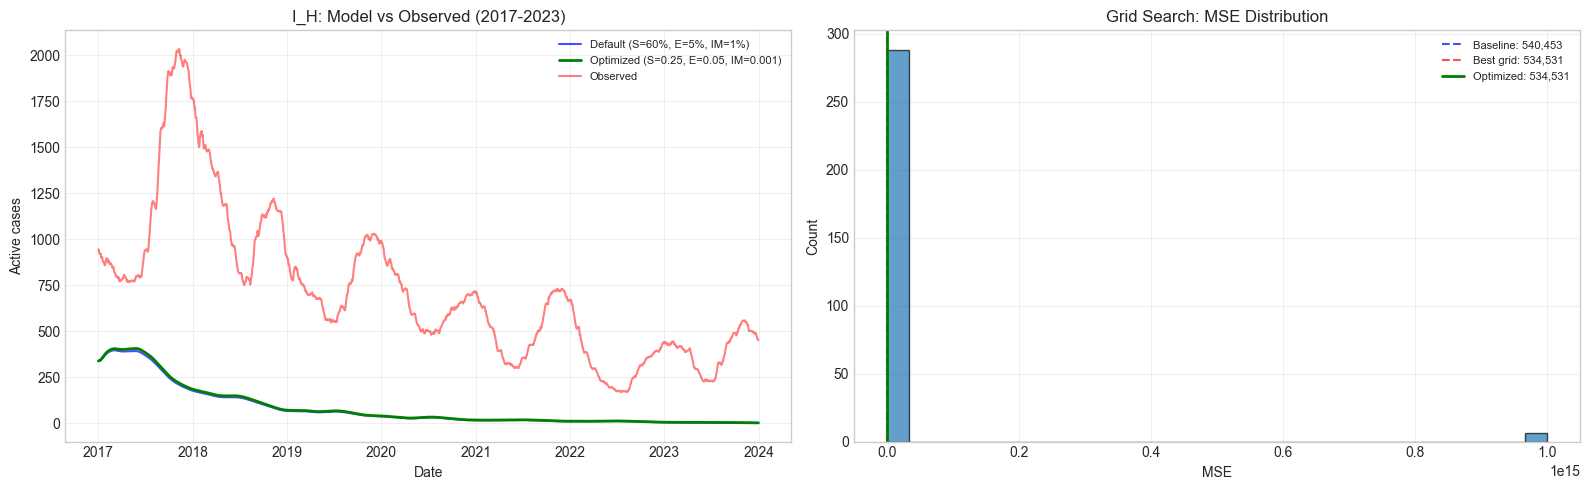


Final Comparison
  Parameter                              Default       Optimized
  ------------------------------------------------------------
  S_H0 / N (2012)                          0.600           0.250
  E_H0 / N (2012)                          0.050           0.050
  I_M0 / M_0 (2012)                        0.010           0.001
  MSE                                    540,453         534,531
  RMSE                                       735             731


In [18]:
#### Baseline simulation
state_default = run_warmup(0.60, 0.05, 0.01)
dates_def, IH_def = run_simulation_from_state(state_default) if state_default is not None else ([], [])

#### Optimized simulation
state_opt = run_warmup(opt_s, opt_e, opt_im)
dates_opt, IH_opt = run_simulation_from_state(state_opt) if state_opt is not None else ([], [])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
if len(IH_def) > 0:
    ax.plot(pd.to_datetime(dates_def), IH_def, 'b-', alpha=0.7, label='Default (S=60%, E=5%, IM=1%)')
if len(IH_opt) > 0:
    ax.plot(pd.to_datetime(dates_opt), IH_opt, 'g-', linewidth=2,
            label=f'Optimized (S={opt_s:.2f}, E={opt_e:.2f}, IM={opt_im:.3f})')
ax.plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', alpha=0.5, label='Observed')
ax.set_title('I_H: Model vs Observed (2017-2023)')
ax.set_xlabel('Date'); ax.set_ylabel('Active cases'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
mse_list = [r[3] for r in grid_results]
ax.hist(mse_list, bins=30, edgecolor='black', alpha=0.7)
ax.axvline(baseline, color='blue', linestyle='--', alpha=0.7, label=f'Baseline: {baseline:,.0f}')
ax.axvline(best_mse, color='red', linestyle='--', alpha=0.7, label=f'Best grid: {best_mse:,.0f}')
ax.axvline(opt_mse, color='green', linestyle='-', linewidth=2, label=f'Optimized: {opt_mse:,.0f}')
ax.set_xlabel('MSE'); ax.set_ylabel('Count')
ax.set_title('Grid Search: MSE Distribution'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal Comparison")
print(f"  {'Parameter':<30} {'Default':>15} {'Optimized':>15}")
print(f"  {'-'*60}")
print(f"  {'S_H0 / N (2012)':<30} {0.60:>15.3f} {opt_s:>15.3f}")
print(f"  {'E_H0 / N (2012)':<30} {0.05:>15.3f} {opt_e:>15.3f}")
print(f"  {'I_M0 / M_0 (2012)':<30} {0.010:>15.3f} {opt_im:>15.3f}")
print(f"  {'MSE':<30} {baseline:>15,.0f} {opt_mse:>15,.0f}")
print(f"  {'RMSE':<30} {np.sqrt(baseline):>15,.0f} {np.sqrt(opt_mse):>15,.0f}")


## Final Simulation: All Compartments

Year-by-year simulation with optimized warm-up ICs.


In [20]:
#### Year-by-year simulation with optimized warm-up ICs
current_state = state_opt.copy()
all_results = []

for year in years:
    N = round(pop_by_year[year])
    start = f"{year}-01-01"
    end = f"{year}-12-31"
    year_climate = climate_data[
        (climate_data['date'] >= start) & (climate_data['date'] <= end)
    ].reset_index(drop=True)
    if USE_SMOOTH_CLIMATE:
        year_climate['temp_med_smooth'] = year_climate['temp_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['precip_med_smooth'] = year_climate['precip_med'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
        year_climate['umid_min_smooth'] = year_climate['umid_min'].rolling(SMOOTH_WINDOW, min_periods=1, center=False).mean()
    num_days = len(year_climate)
    def ode_func(t, z):
        return seirs_sei_ode(t, z, N, year_climate,
                            T_prime, B_E, p_ME, p_ML, p_MP, tau_E, tau_P,
                            c1, c2, D1, b1, b2, A, B, C, DD,
                            Tmin, optimal_temp_plasm, critical_max_temp_plasm,
                            optimal_temp_anop, critical_max_temp_anop, critical_min_temp_anop,
                            gamma, R_L, M_prime, tau_H, omega,
                            M_min=M_min, permanent_factor=permanent_factor,
                            use_smooth_climate=USE_SMOOTH_CLIMATE)
    sol = solve_ivp(ode_func, [0, num_days], current_state,
                    t_eval=np.linspace(0, num_days, num_days*10), method='LSODA')
    all_results.append({'year': year, 'N': N, 'sol': sol, 'climate': year_climate})
    current_state = sol.y[:, -1].copy()
    print(f"{year}: Final I_H={round(current_state[2]):>5}, I_M={round(current_state[6]):>5}")

print("\nAll years simulated successfully!")


2017: Final I_H=  185, I_M=   91
2018: Final I_H=   71, I_M=   42
2019: Final I_H=   40, I_M=   23
2020: Final I_H=   17, I_M=    8
2021: Final I_H=   11, I_M=    7
2022: Final I_H=    6, I_M=    1
2023: Final I_H=    2, I_M=    1

All years simulated successfully!


findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


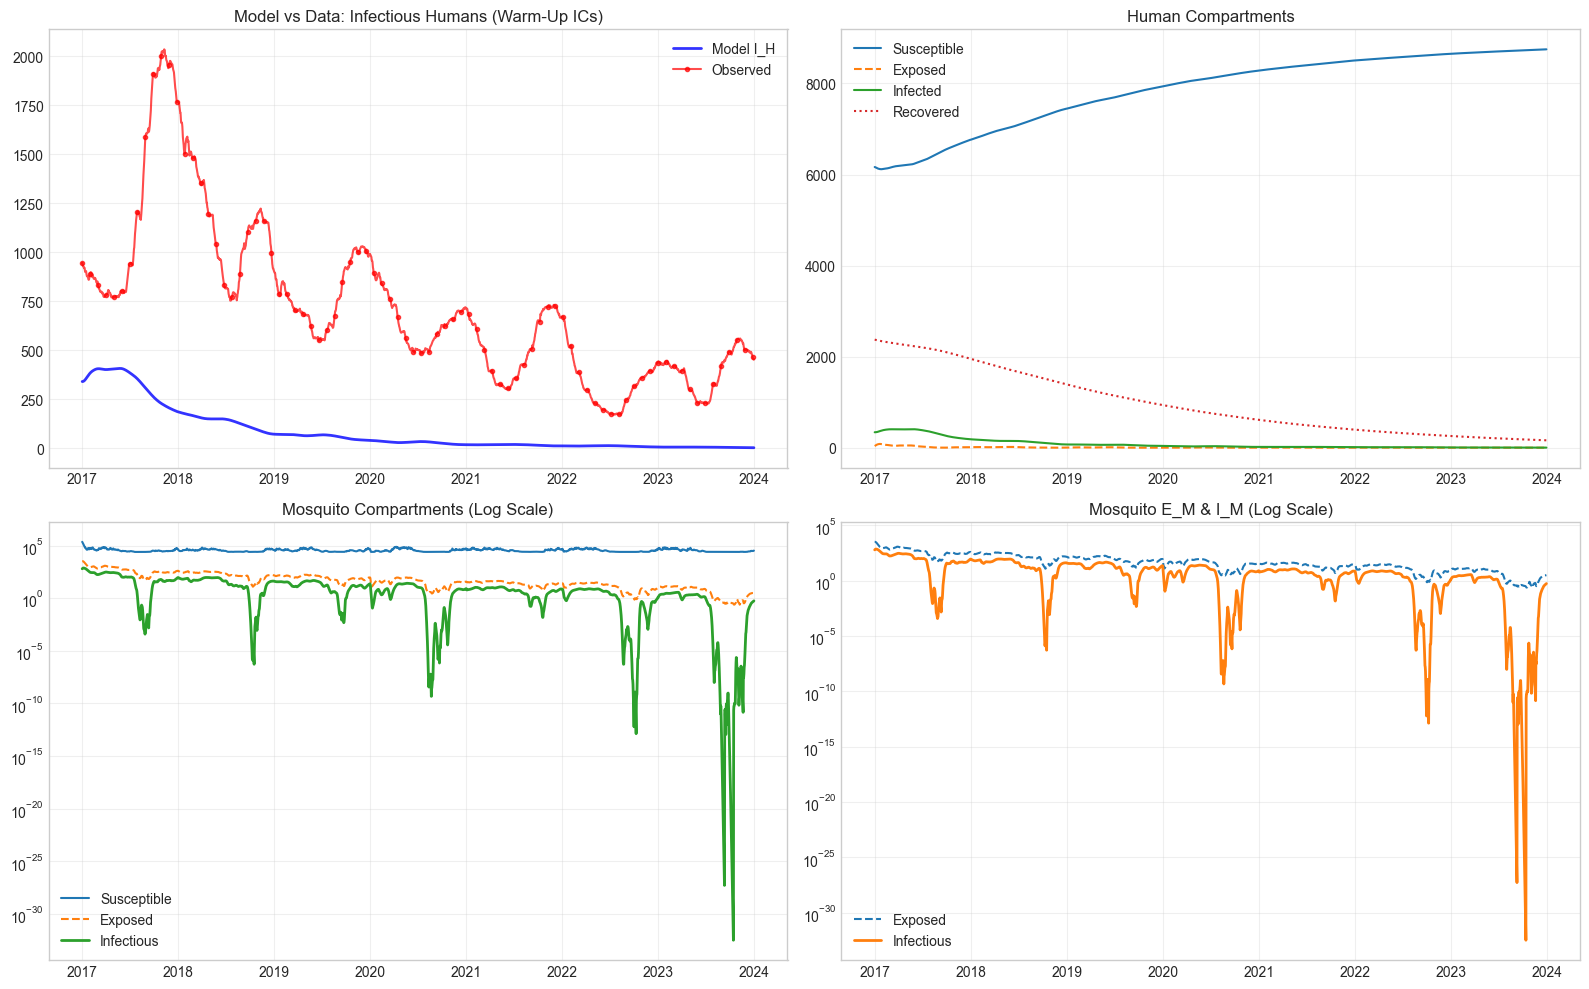

In [21]:
#### Combine and plot all compartments
combined_df = pd.DataFrame()
for res in all_results:
    sol = res['sol']; climate = res['climate']
    t_interp = np.linspace(0, sol.t[-1], len(climate))
    interp = [interp1d(sol.t, sol.y[i])(t_interp) for i in range(7)]
    df = pd.DataFrame({
        'date': pd.to_datetime(climate['date']).values,
        'S_H': interp[0], 'E_H': interp[1], 'I_H': interp[2], 'R_H': interp[3],
        'S_M': interp[4], 'E_M': interp[5], 'I_M': interp[6], 'N': res['N']
    })
    combined_df = pd.concat([combined_df, df]).reset_index(drop=True)

combined_df['date'] = pd.to_datetime(combined_df['date'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].plot(combined_df['date'], combined_df['I_H'], 'b-', linewidth=2, label='Model I_H', alpha=0.8)
axes[0,0].plot(rural_cases_df['date'], rural_cases_df['active_total'], 'r-', linewidth=1.5,
        label='Observed', alpha=0.7, marker='o', markersize=3, markevery=30)
axes[0,0].set_title('Model vs Data: Infectious Humans (Warm-Up ICs)')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(combined_df['date'], combined_df['S_H'], label='Susceptible')
axes[0,1].plot(combined_df['date'], combined_df['E_H'], label='Exposed', linestyle='--')
axes[0,1].plot(combined_df['date'], combined_df['I_H'], label='Infected', linestyle='-')
axes[0,1].plot(combined_df['date'], combined_df['R_H'], label='Recovered', linestyle=':')
axes[0,1].set_title('Human Compartments'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(combined_df['date'], combined_df['S_M'], label='Susceptible', linewidth=1.5)
axes[1,0].plot(combined_df['date'], combined_df['E_M'], label='Exposed', linewidth=1.5, linestyle='--')
axes[1,0].plot(combined_df['date'], combined_df['I_M'], label='Infectious', linewidth=2)
axes[1,0].set_yscale('log'); axes[1,0].set_title('Mosquito Compartments (Log Scale)')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3, which='both')

axes[1,1].plot(combined_df['date'], combined_df['E_M'], label='Exposed', linewidth=1.5, linestyle='--')
axes[1,1].plot(combined_df['date'], combined_df['I_M'], label='Infectious', linewidth=2)
axes[1,1].set_yscale('log'); axes[1,1].set_title('Mosquito E_M & I_M (Log Scale)')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()
